In [2]:
# Import Meteostat library and dependencies
from datetime import datetime
import matplotlib.pyplot as plt
from meteostat import Point, Daily, Hourly
import pandas as pd
import json
import numpy as np
import seaborn as sns

## Adding data for 2016 and 1980

In [4]:
MISSING_YEARS = [1980, 2016]
MISSING_VARS = [
    "apparent_temperature_min",
    "apparent_temperature_max",
    "wind_speed_10m_mean",
]

def fetch_missing_year(y, vars_):
    start, end = f"{y}-01-01", f"{y}-12-31"
    return get_daily(start, end, vars_)

fix_frames = []
for y in MISSING_YEARS:
    try:
        d = fetch_missing_year(y, MISSING_VARS)
        fix_frames.append(d)
        print(f"patched {y}")
    except Exception as e:
        print(f"{y} failed: {e}")

df_fix = pd.concat(fix_frames, ignore_index=True)
df_fix["time"] = pd.to_datetime(df_fix["time"])

patched 1980
patched 2016


In [13]:
df_weather

,time,temperature_2m_max,temperature_2m_min,temperature_2m_mean,precipitation_sum,precipitation_hours,apparent_temperature_max,apparent_temperature_min,sunshine_duration,wind_speed_10m_max,wind_gusts_10m_max,wind_speed_10m_mean,uv_index_max
0,1980-01-01,12.7,8.2,9.9,0.0,0.0,NaN,NaN,NaN,21.7,38.2,13.7,NaN
1,1980-01-02,8.9,5.4,6.5,3.0,8.0,NaN,NaN,NaN,15.4,28.1,11.9,NaN
2,1980-01-03,5.9,4.6,5.2,7.4,15.0,NaN,NaN,NaN,18.4,30.2,12.8,NaN
3,1980-01-04,5.4,-0.5,3.3,1.4,5.0,NaN,NaN,NaN,27.1,47.9,20.7,NaN
4,1980-01-05,4.0,-3.7,-0.1,0.0,0.0,NaN,NaN,NaN,18.4,31.7,10.6,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
16797,2025-12-27 00:00:00,11.6,2.2,6.5,0.0,0.0,9.1,-0.6,32850.54,6.5,16.2,3.8,NaN
16798,2025-12-28 00:00:00,13.6,1.9,7.4,0.0,0.0,10.6,-0.4,32504.41,9.4,19.1,4.1,NaN
16799,2025-12-29 00:00:00,17.5,4.3,10.6,0.0,0.0,14.6,1.8,31347.74,10.1,22.7,7.2,NaN
16800,2025-12-30 00:00:00,13.5,7.8,10.1,0.0,0.0,10.1,5.3,32170.74,14.8,36.4,11.3,NaN


In [7]:
weather_fp = '../public/data/weather_shanghai.csv'
df_weather = pd.read_csv(weather_fp)


In [10]:
df_weather = df_weather[['time', 'temperature_2m_max', 'temperature_2m_min',
       'temperature_2m_mean', 'precipitation_sum', 'precipitation_hours',
       'apparent_temperature_max', 'apparent_temperature_min',
       'sunshine_duration', 'wind_speed_10m_max', 'wind_gusts_10m_max',
       'wind_speed_10m_mean', 'uv_index_max']]

In [14]:
MISSING_VARS = [
    "apparent_temperature_min",
    "apparent_temperature_max",
    "wind_speed_10m_mean",
]

# parse mixed formats + normalize to midnight (date key)
df_weather["time"] = pd.to_datetime(df_weather["time"], format="mixed").dt.normalize()
df_fix["time"] = pd.to_datetime(df_fix["time"], format="mixed").dt.normalize()

# merge only needed cols to avoid collisions
df_weather = df_weather.merge(
    df_fix[["time"] + MISSING_VARS],
    on="time",
    how="left",
    suffixes=("", "_new"),
)

for v in MISSING_VARS:
    df_weather[v] = df_weather[v].fillna(df_weather[f"{v}_new"])
    df_weather.drop(columns=[f"{v}_new"], inplace=True)


In [20]:
df_weather.isna().sum()

time                            0
temperature_2m_max              0
temperature_2m_min              0
temperature_2m_mean             0
precipitation_sum               0
precipitation_hours             0
apparent_temperature_max        0
apparent_temperature_min        0
sunshine_duration             366
wind_speed_10m_max              0
wind_gusts_10m_max              0
wind_speed_10m_mean           365
uv_index_max                16802
dtype: int64

In [25]:
PATCH_YEAR = 1980
PATCH_VARS = ['wind_speed_10m_mean']

df_patch = get_daily(f"{PATCH_YEAR}-01-01", f"{PATCH_YEAR}-12-31", PATCH_VARS)
df_patch["time"] = pd.to_datetime(df_patch["time"], format="mixed").dt.normalize()

df_weather["time"] = pd.to_datetime(df_weather["time"], format="mixed").dt.normalize()

df_weather = df_weather.merge(df_patch[["time"] + PATCH_VARS], on="time", how="left", suffixes=("", "_new"))
for v in PATCH_VARS:
    df_weather[v] = df_weather[v].fillna(df_weather[f"{v}_new"])
    df_weather.drop(columns=[f"{v}_new"], inplace=True)


In [26]:
y = 1980
dates_weather = set(df_weather.loc[df_weather["time"].dt.year == y, "time"])
dates_fix     = set(df_fix.loc[df_fix["time"].dt.year == y, "time"])
missing_in_weather = sorted(dates_fix - dates_weather)
missing_in_fix     = sorted(dates_weather - dates_fix)
missing_in_weather[:10], missing_in_fix[:10]


([], [])

In [28]:
weather_fp = '../public/data/weather_shanghai2.csv'
df_weather.to_csv(weather_fp, ignore)

## Loading the daily dataset

In [4]:
import requests, pandas as pd, time
from requests.exceptions import HTTPError, RequestException

lat, lon = 31.1667, 121.4333
years = range(2026, 2028)  # inclusive end: 2025
TZ = "Asia/Shanghai"

# two groups: core (almost always available) + extras (may fail for older years)
GROUPS = [
    ["temperature_2m_max","temperature_2m_min","temperature_2m_mean","precipitation_sum","precipitation_hours"],
    ["apparent_temperature_max","apparent_temperature_min","sunshine_duration",
     "wind_speed_10m_max","wind_gusts_10m_max","wind_speed_10m_mean","humidity_2m_mean","uv_index_max"],
]

def get_daily(start, end, vars_):
    """Try one request with a list of vars; fallback by removing uv_index_max once."""
    params = {
        "latitude": lat, "longitude": lon,
        "start_date": start, "end_date": end,
        "daily": ",".join(vars_), "timezone": TZ
    }
    try:
        r = requests.get("https://archive-api.open-meteo.com/v1/archive", params=params, timeout=45)
        r.raise_for_status()
        return pd.DataFrame(r.json()["daily"])
    except HTTPError:
        if "uv_index_max" in vars_:  # retry once without UV
            v2 = [v for v in vars_ if v != "uv_index_max"]
            params["daily"] = ",".join(v2)
            r = requests.get("https://archive-api.open-meteo.com/v1/archive", params=params, timeout=45)
            r.raise_for_status()
            return pd.DataFrame(r.json()["daily"])
        raise

def fetch_year(y):
    start, end = f"{y}-01-01", f"{y}-12-31"
    base = None
    for grp in GROUPS:
        try:
            df = get_daily(start, end, grp)
            base = df if base is None else base.merge(df, on="time", how="outer")
        except RequestException:
            # salvage: try each var individually
            for v in grp:
                try:
                    dfv = get_daily(start, end, [v])
                    base = dfv if base is None else base.merge(dfv, on="time", how="outer")
                except RequestException:
                    pass  # skip this var for this year
        time.sleep(0.3)  # be polite
    return base

frames = []
for y in years:
    try:
        dfy = fetch_year(y)
        if dfy is not None and len(dfy):
            frames.append(dfy)
            print(f"{y}: {len(dfy)} rows")
        else:
            print(f"{y}: no data")
    except Exception as e:
        print(f"{y}: skipped ({e})")

# df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
# df["time"] = pd.to_datetime(df["time"])
# df = df.sort_values("time").reset_index(drop=True)
# print(df.shape)


2026: no data
2027: no data


In [6]:
frames

[]

In [5]:
df = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
df["time"] = pd.to_datetime(df["time"])
df = df.sort_values("time").reset_index(drop=True)
print(df.shape)

KeyError: 'time'

In [ ]:
df.tail(2)

In [7]:
!ls ../

Nbs	   cleaned_weather_shanghai.csv  main.py  scraping_precip.ipynb
README.md  main.html			 public   src


In [17]:
df.columns

Index(['time', 'temperature_2m_max', 'temperature_2m_min',
       'temperature_2m_mean', 'precipitation_sum', 'precipitation_hours',
       'apparent_temperature_max', 'apparent_temperature_min',
       'sunshine_duration', 'wind_speed_10m_max', 'wind_gusts_10m_max',
       'wind_speed_10m_mean', 'uv_index_max'],
      dtype='object')

In [22]:
filtered_df = df[df['time']>'2025-10-11'].copy()

In [10]:
old_df = pd.read_csv('../cleaned_weather_shanghai.csv')

In [23]:
filtered_old_df = old_df[['time', 'temperature_2m_max', 'temperature_2m_min',
       'temperature_2m_mean', 'precipitation_sum', 'precipitation_hours',
       'apparent_temperature_max', 'apparent_temperature_min',
       'sunshine_duration', 'wind_speed_10m_max', 'wind_gusts_10m_max',
       'wind_speed_10m_mean', 'uv_index_max']]

In [27]:
cleaned_df = pd.concat([filtered_old_df, filtered_df])

In [28]:
cleaned_df.to_csv('weather2025.csv')

In [40]:
np.arange(cleaned_df.shape[0])

array([    0,     1,     2, ..., 16799, 16800, 16801], shape=(16802,))

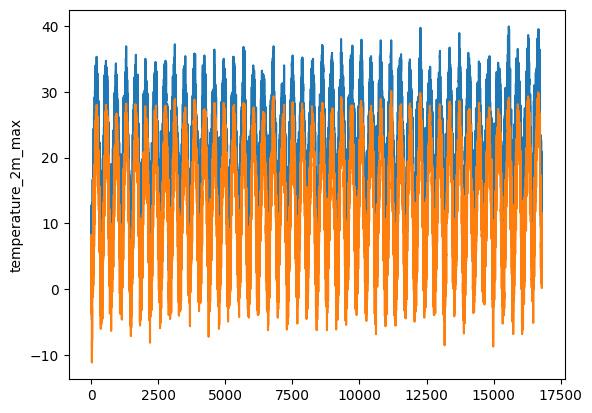

In [47]:
sns.lineplot(x=np.arange(cleaned_df.shape[0]), y=cleaned_df['temperature_2m_max'])
sns.lineplot(x=np.arange(cleaned_df.shape[0]), y=cleaned_df['temperature_2m_min']);

In [95]:
import requests, pandas as pd

lat, lon = 31.1667, 121.4333
start, end = "2025-01-01", "2025-10-11"  # today is Oct 11

core = ["temperature_2m_max","temperature_2m_min","temperature_2m_mean","precipitation_sum"]

r = requests.get("https://archive-api.open-meteo.com/v1/archive",
                 params={"latitude":lat,"longitude":lon,
                         "start_date":start,"end_date":end,
                         "daily":",".join(core),"timezone":"Asia/Shanghai"},
                 timeout=45)
r.raise_for_status()
df2025 = pd.DataFrame(r.json()["daily"])
df2025["time"] = pd.to_datetime(df2025["time"])

# append to your existing df
df = pd.concat([df, df2025], ignore_index=True).drop_duplicates("time").sort_values("time")


In [107]:
# General, resilient 2025 fetch (per-variable, per-month; fills what exists and skips what doesn’t)
import requests, pandas as pd

lat, lon = 31.1667, 121.4333
start_date, end_date = pd.Timestamp("2025-01-01"), pd.Timestamp("2025-10-11")
url = "https://archive-api.open-meteo.com/v1/archive"
vars25 = [
    "temperature_2m_mean","temperature_2m_max","temperature_2m_min",
    "apparent_temperature_max","apparent_temperature_min",
    "precipitation_sum","precipitation_hours","sunshine_duration",
    "uv_index_max","wind_speed_10m_max","wind_gusts_10m_max","wind_speed_10m_mean",
    "humidity_2m_mean","shortwave_radiation_sum","et0_fao_evapotranspiration"
]

# monthly windows (avoid long-range empties)
months = pd.date_range(start_date, end_date, freq="MS")
windows = [(m, min(m + pd.offsets.MonthEnd(0), end_date)) for m in months]

def fetch_var_monthly(var):
    frames = []
    for s, e in windows:
        try:
            r = requests.get(url, params={
                "latitude": lat, "longitude": lon,
                "start_date": s.strftime("%Y-%m-%d"),
                "end_date":   e.strftime("%Y-%m-%d"),
                "daily": var, "timezone": "Asia/Shanghai"
            }, timeout=45)
            r.raise_for_status()
            j = r.json().get("daily", {})
            if j and var in j:
                frames.append(pd.DataFrame({"time": j["time"], var: j[var]}))
        except Exception:
            pass
    if not frames:  # no data for this var (fine)
        return pd.DataFrame(columns=["time", var])
    out = pd.concat(frames, ignore_index=True)
    out["time"] = pd.to_datetime(out["time"])
    return out.drop_duplicates("time")

# build skeleton from temperature_2m_mean (or time index if absent)
base = fetch_var_monthly("temperature_2m_mean")
if base.empty:
    base = pd.DataFrame({"time": pd.date_range(start_date, end_date, freq="D")})

for v in vars25:
    if v in base.columns: 
        continue
    chunk = fetch_var_monthly(v)
    base = base.merge(chunk, on="time", how="left")

# append/replace 2025 block in your master df
try:
    df
    df = pd.concat([df[df["time"] < start_date], df[df["time"] > end_date], base], ignore_index=True)
    df = df.drop_duplicates("time").sort_values("time").reset_index(drop=True)
except NameError:
    df = base.sort_values("time").reset_index(drop=True)

print("2025 columns added:", [c for c in base.columns if c != "time"])
print("df shape:", df.shape)


2025 columns added: ['temperature_2m_mean', 'temperature_2m_max', 'temperature_2m_min', 'apparent_temperature_max', 'apparent_temperature_min', 'precipitation_sum', 'precipitation_hours', 'sunshine_duration', 'uv_index_max', 'wind_speed_10m_max', 'wind_gusts_10m_max', 'wind_speed_10m_mean', 'humidity_2m_mean', 'shortwave_radiation_sum', 'et0_fao_evapotranspiration']
df shape: (16690, 16)


In [108]:
# import requests, json
# lat, lon = 31.1667, 121.4333
# r = requests.get(
#     "https://archive-api.open-meteo.com/v1/archive",
#     params={
#         "latitude": lat, "longitude": lon,
#         "start_date": "2025-09-01", "end_date": "2025-09-30",
#         "daily": "precipitation_hours",
#         "timezone": "Asia/Shanghai"
#     },
#     timeout=30
# )
# print(r.status_code)
# print(json.dumps(r.json(), indent=2)[:1000])


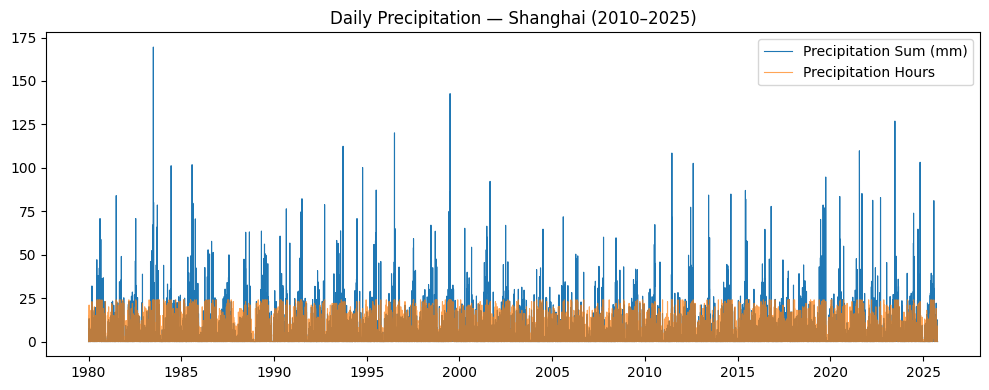

In [159]:


plt.figure(figsize=(10,4))
plt.plot(df["time"], df["precipitation_sum"], label="Precipitation Sum (mm)", lw=0.8)
plt.plot(df["time"], df["precipitation_hours"], label="Precipitation Hours", lw=0.8, alpha=0.7)
plt.legend()
plt.title("Daily Precipitation — Shanghai (2010–2025)")
plt.tight_layout()
plt.show()


In [138]:
# import requests, pandas as pd, time

# def get_march_2025(vars_list, lat=31.1667, lon=121.4333):
#     """Fetch March 2025 daily data from Open-Meteo for selected variables."""
#     url = "https://archive-api.open-meteo.com/v1/archive"
#     s, e = "2025-03-01", "2025-03-31"
#     frames = []
#     for v in vars_list:
#         for attempt in range(3):
#             try:
#                 r = requests.get(
#                     url,
#                     params={
#                         "latitude": lat, "longitude": lon,
#                         "start_date": s, "end_date": e,
#                         "daily": v, "timezone": "Asia/Shanghai"
#                     },
#                     timeout=45,
#                 )
#                 r.raise_for_status()
#                 j = r.json().get("daily", {})
#                 if v in j:
#                     frames.append(pd.DataFrame({"time": j["time"], v: j[v]}))
#                     print(f"{v} ok")
#                 else:
#                     print(f"{v} empty")
#                 break
#             except Exception as err:
#                 print(f"{v} try {attempt+1} → {err}")
#                 time.sleep(2)
#         else:
#             print(f"{v} failed after retries")
#     if not frames:
#         return pd.DataFrame()
#     df_march = frames[0]
#     for f in frames[1:]:
#         df_march = df_march.merge(f, on="time", how="outer")
#     df_march["time"] = pd.to_datetime(df_march["time"])
#     return df_march.sort_values("time").reset_index(drop=True)
# vars_march = [
#     "temperature_2m_mean","temperature_2m_max","temperature_2m_min",
#     "apparent_temperature_max","apparent_temperature_min",
#     "precipitation_sum","precipitation_hours","sunshine_duration",
#     "uv_index_max","wind_speed_10m_max","wind_gusts_10m_max",
#     "wind_speed_10m_mean","humidity_2m_mean",
#     "shortwave_radiation_sum","et0_fao_evapotranspiration"
# ]

# march2025 = get_march_2025(vars_march)
# print(march2025.head(), march2025.shape)


In [146]:
# robust merge-in for March 2025 (adds any missing dates)
df = (
    pd.concat([df, march2025], ignore_index=True)
      .drop_duplicates(subset=["time"], keep="last")
      .sort_values("time")
      .reset_index(drop=True)
)


In [140]:
# Merge March 2025 into your master df (non-destructive; only updates those days/cols)

import pandas as pd

# ensure datetime
df["time"] = pd.to_datetime(df["time"])
march2025["time"] = pd.to_datetime(march2025["time"])

base = df.set_index("time")
m = march2025.set_index("time")

# add any new columns from March frame
for c in m.columns:
    if c not in base.columns:
        base[c] = pd.NA

# update March rows/values (keeps existing data elsewhere; doesn't overwrite with NaN)
base.update(m)

df = base.reset_index().sort_values("time")


In [150]:
import requests, pandas as pd

lat, lon = 31.1667, 121.4333
start, end = "1981-01-01", "1981-12-31"
url = "https://archive-api.open-meteo.com/v1/archive"

vars81 = [
    "temperature_2m_mean","temperature_2m_max","temperature_2m_min",
    "apparent_temperature_max","apparent_temperature_min",
    "precipitation_sum","precipitation_hours","sunshine_duration",
    "uv_index_max","wind_speed_10m_max","wind_gusts_10m_max",
    "wind_speed_10m_mean","humidity_2m_mean",
    "shortwave_radiation_sum","et0_fao_evapotranspiration"
]

frames = []
for v in vars81:
    try:
        r = requests.get(
            url,
            params={
                "latitude": lat, "longitude": lon,
                "start_date": start, "end_date": end,
                "daily": v, "timezone": "Asia/Shanghai"
            },
            timeout=45,
        )
        r.raise_for_status()
        j = r.json().get("daily", {})
        if v in j:
            frames.append(pd.DataFrame({"time": j["time"], v: j[v]}))
            print(f"{v} ok")
    except Exception as e:
        print(f"{v} skipped → {e}")

df1981 = frames[0]
for f in frames[1:]:
    df1981 = df1981.merge(f, on="time", how="outer")
df1981["time"] = pd.to_datetime(df1981["time"])

# merge 1981 into master df
df = (
    pd.concat([df, df1981], ignore_index=True)
      .drop_duplicates(subset=["time"], keep="last")
      .sort_values("time")
      .reset_index(drop=True)
)
print("Merged 1981:", df1981.shape, "→ df shape:", df.shape)


temperature_2m_mean ok
temperature_2m_max ok
temperature_2m_min ok
apparent_temperature_max ok
apparent_temperature_min ok
precipitation_sum ok
precipitation_hours ok
sunshine_duration ok
uv_index_max ok
wind_speed_10m_max ok
wind_gusts_10m_max ok
wind_speed_10m_mean ok
humidity_2m_mean skipped → 400 Client Error: Bad Request for url: https://archive-api.open-meteo.com/v1/archive?latitude=31.1667&longitude=121.4333&start_date=1981-01-01&end_date=1981-12-31&daily=humidity_2m_mean&timezone=Asia%2FShanghai
shortwave_radiation_sum ok
et0_fao_evapotranspiration ok
Merged 1981: (365, 15) → df shape: (16721, 16)


In [148]:
# df.to_csv('weather_shanghai.csv')
# df[(df['time']>'2025-02-25')&(df['time']<'2025-04-25')]

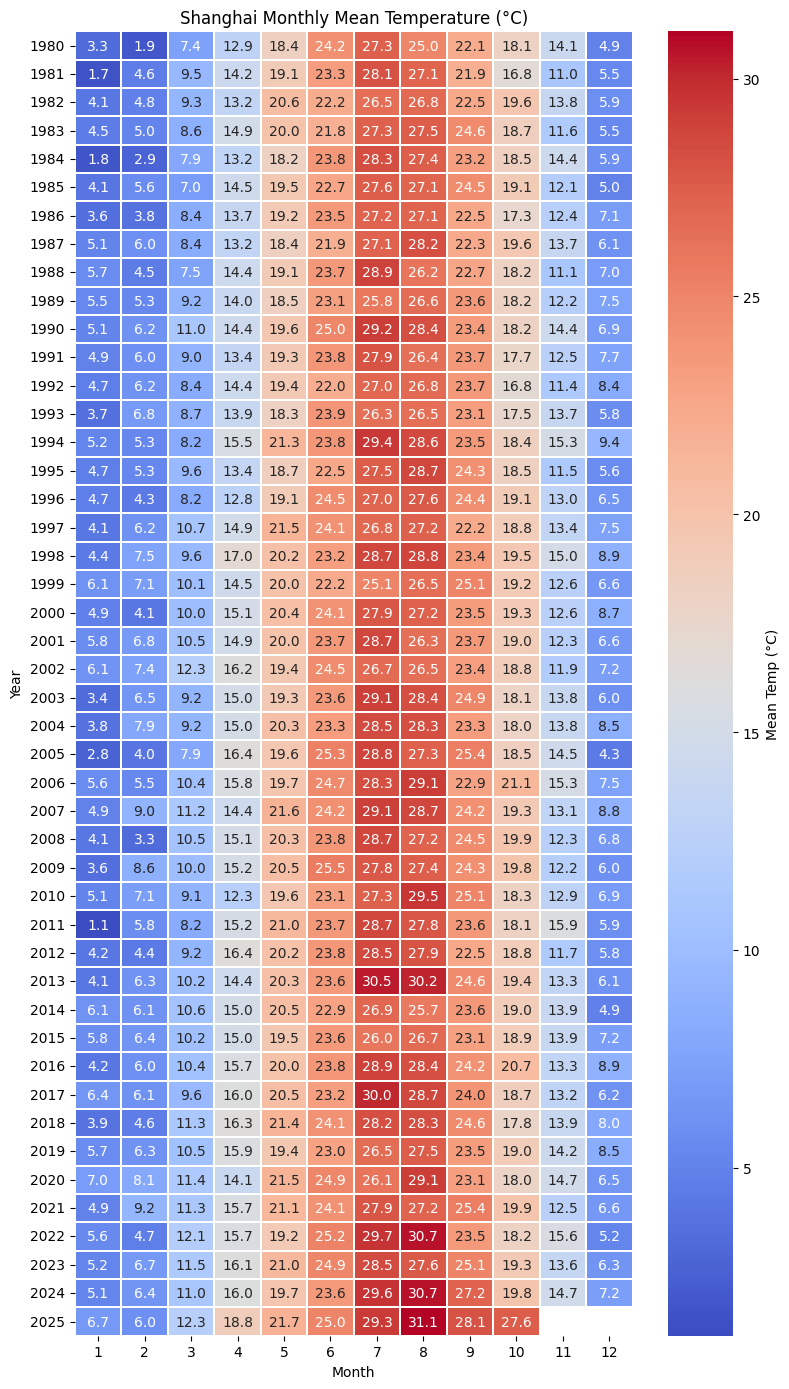

In [151]:
monthly_average = (
    df.assign(year=df["time"].dt.year, month=df["time"].dt.month)
      .groupby(["year","month"])["temperature_2m_mean"]
      .mean().unstack()
)
plt.figure(figsize=(8,14))
sns.heatmap(monthly_average, cmap="coolwarm", 
            cbar_kws={"label":"Mean Temp (°C)"}, linewidths=.3, annot=True,  fmt=".1f")
plt.title("Shanghai Monthly Mean Temperature (°C)")
plt.xlabel("Month"); plt.ylabel("Year")
plt.tight_layout()
plt.show()

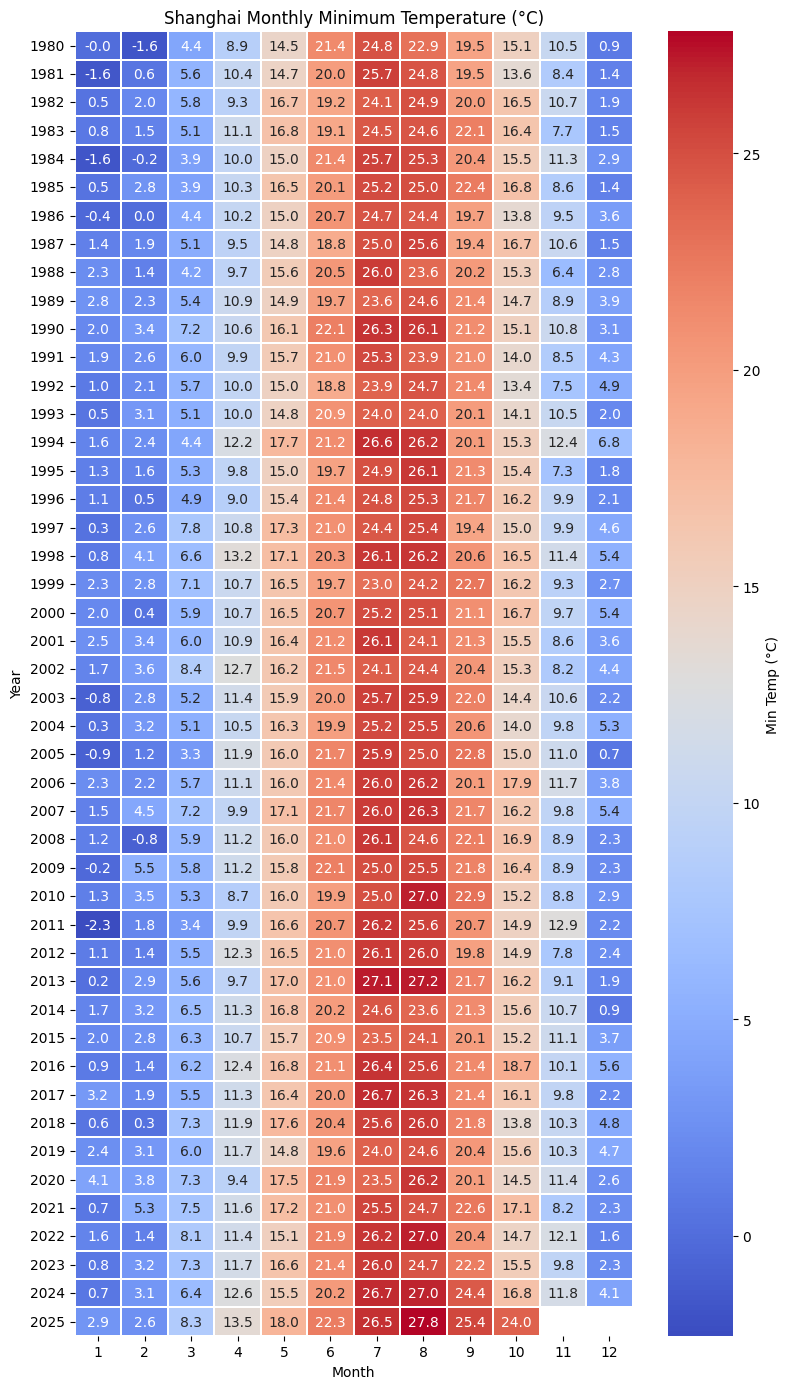

In [152]:
monthly_min = (
    df.assign(year=df["time"].dt.year, month=df["time"].dt.month)
      .groupby(["year","month"])["temperature_2m_min"]
      .mean().unstack()
)
plt.figure(figsize=(8,14))
sns.heatmap(monthly_min, cmap="coolwarm",
            cbar_kws={"label":"Min Temp (°C)"}, linewidths=.3, annot=True, fmt=".1f")
plt.title("Shanghai Monthly Minimum Temperature (°C)")
plt.xlabel("Month"); plt.ylabel("Year")
plt.tight_layout(); plt.show()


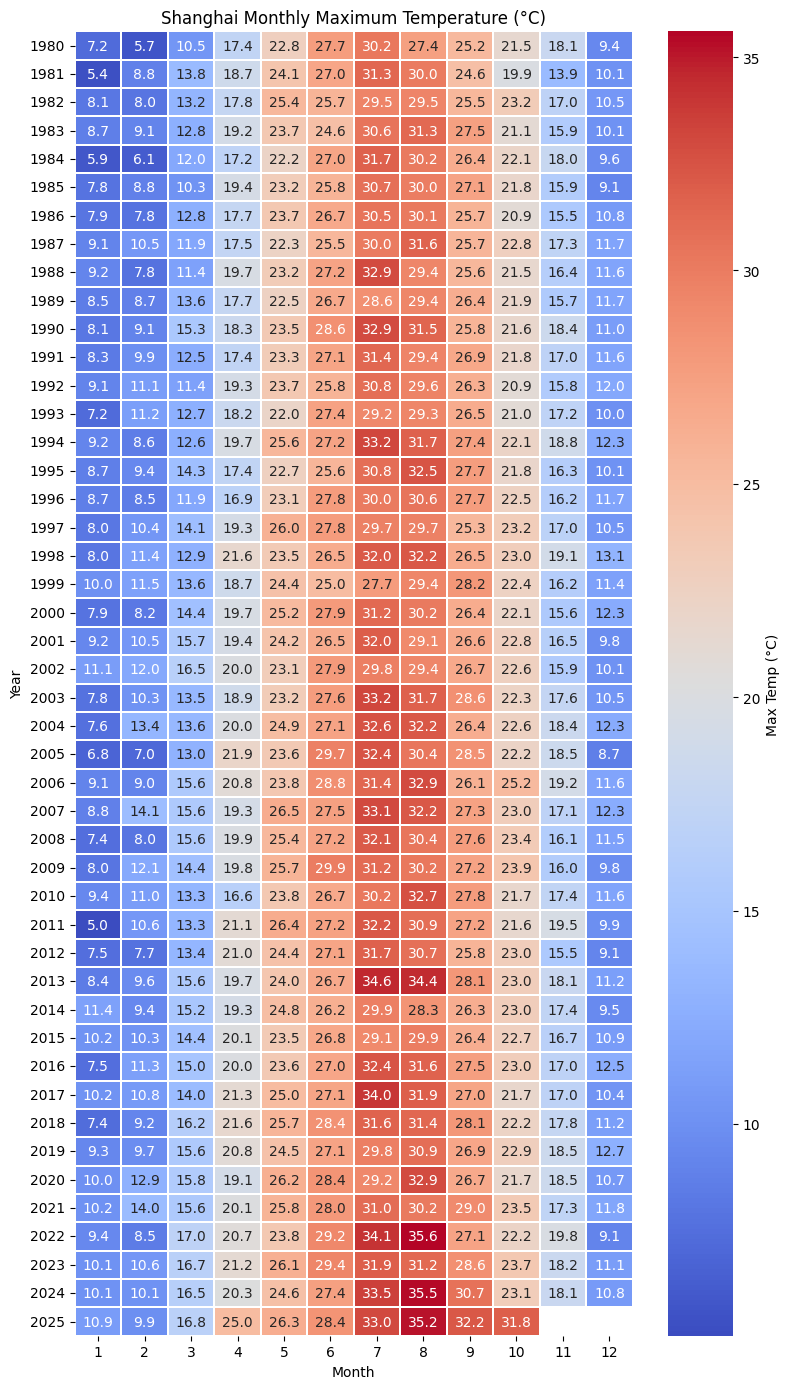

In [154]:
monthly_max = (
    df.assign(year=df["time"].dt.year, month=df["time"].dt.month)
      .groupby(["year","month"])["temperature_2m_max"]
      .mean().unstack()
)
plt.figure(figsize=(8,14))
sns.heatmap(monthly_max, cmap="coolwarm",
            cbar_kws={"label":"Max Temp (°C)"}, linewidths=.3, annot=True, fmt=".1f")
plt.title("Shanghai Monthly Maximum Temperature (°C)")
plt.xlabel("Month"); plt.ylabel("Year")
plt.tight_layout(); plt.show()


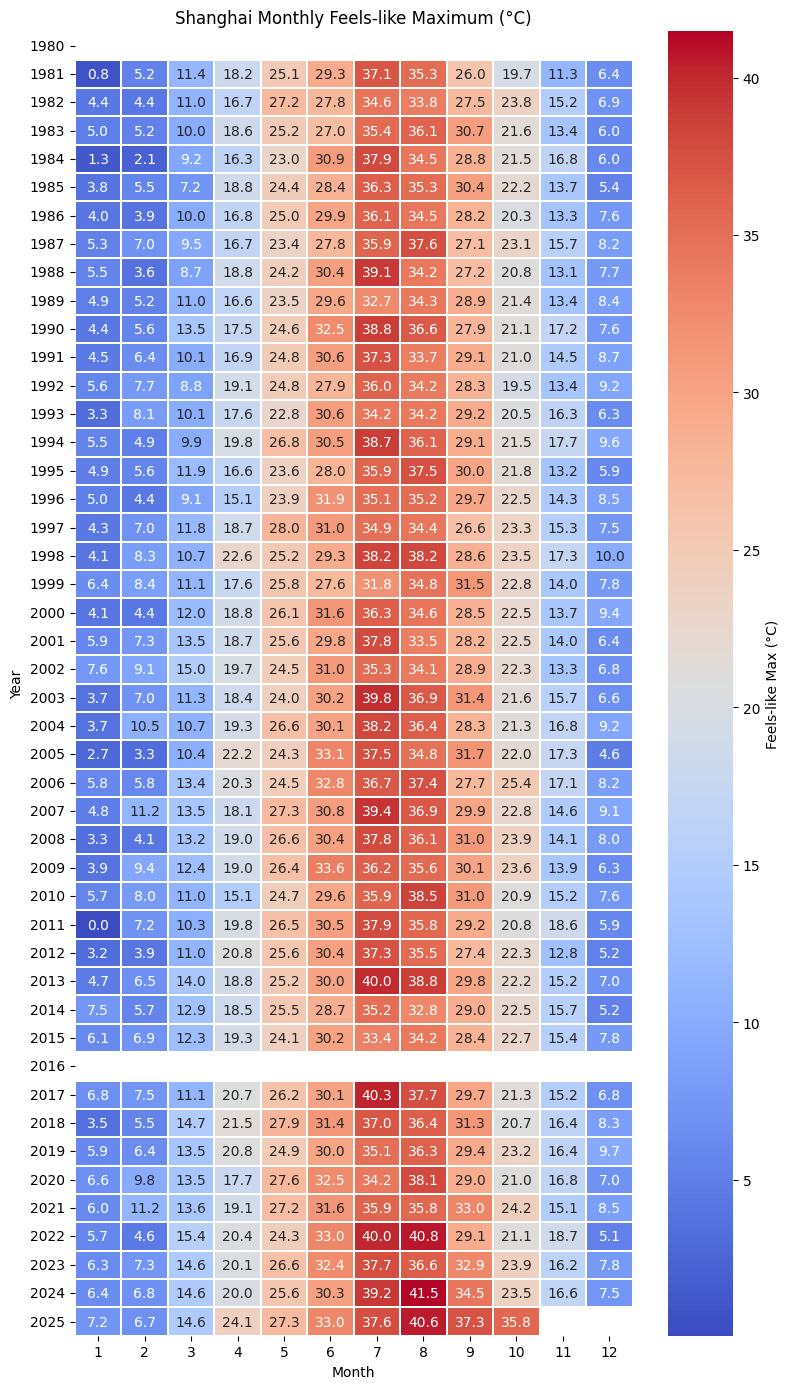

In [155]:
monthly_app_max = (
    df.assign(year=df["time"].dt.year, month=df["time"].dt.month)
      .groupby(["year","month"])["apparent_temperature_max"]
      .mean().unstack()
)
plt.figure(figsize=(8,14))
sns.heatmap(monthly_app_max, cmap="coolwarm",
            cbar_kws={"label":"Feels-like Max (°C)"}, linewidths=.3, annot=True, fmt=".1f")
plt.title("Shanghai Monthly Feels-like Maximum (°C)")
plt.xlabel("Month"); plt.ylabel("Year")
plt.tight_layout(); plt.show()


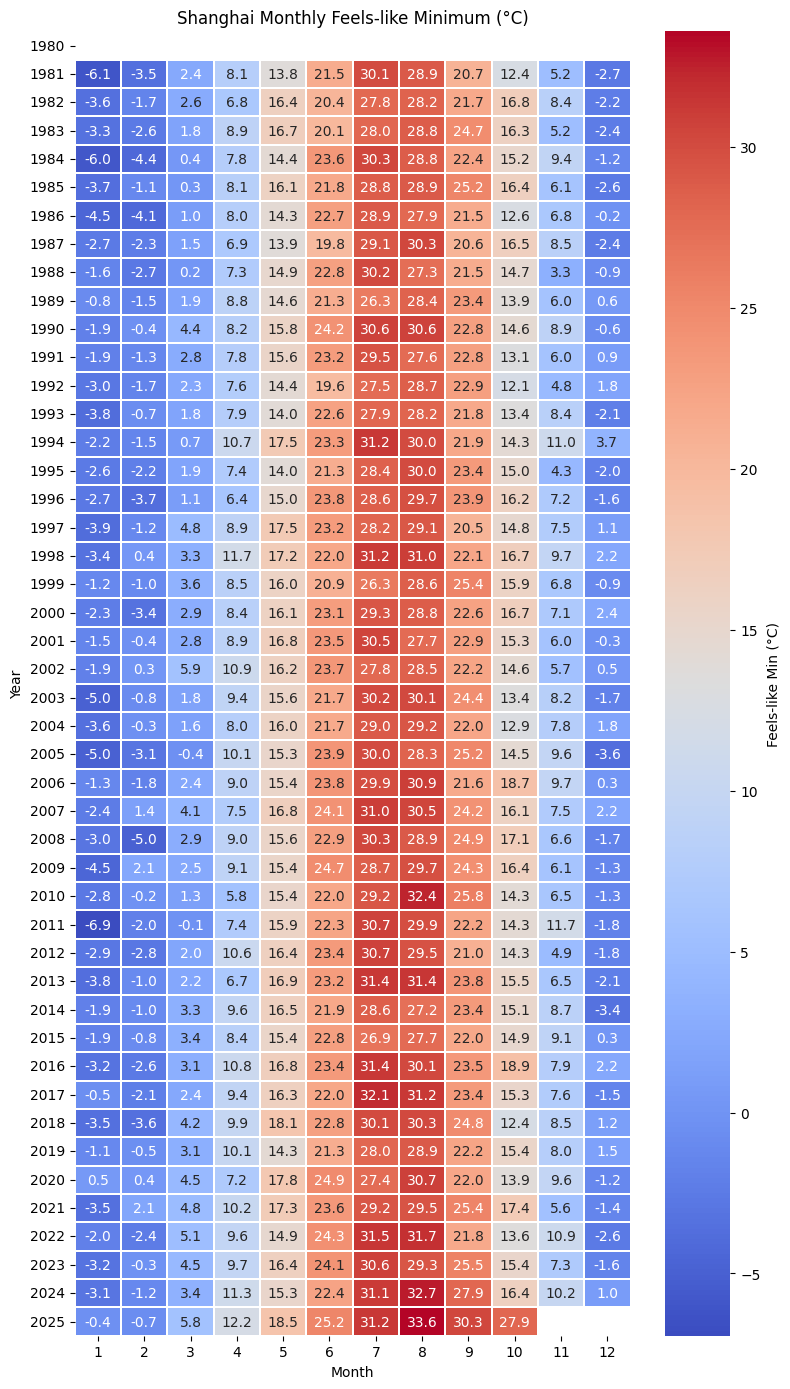

In [156]:
monthly_app_min = (
    df.assign(year=df["time"].dt.year, month=df["time"].dt.month)
      .groupby(["year","month"])["apparent_temperature_min"]
      .mean().unstack()
)
plt.figure(figsize=(8,14))
sns.heatmap(monthly_app_min, cmap="coolwarm",
            cbar_kws={"label":"Feels-like Min (°C)"}, linewidths=.3, annot=True, fmt=".1f")
plt.title("Shanghai Monthly Feels-like Minimum (°C)")
plt.xlabel("Month"); plt.ylabel("Year")
plt.tight_layout(); plt.show()


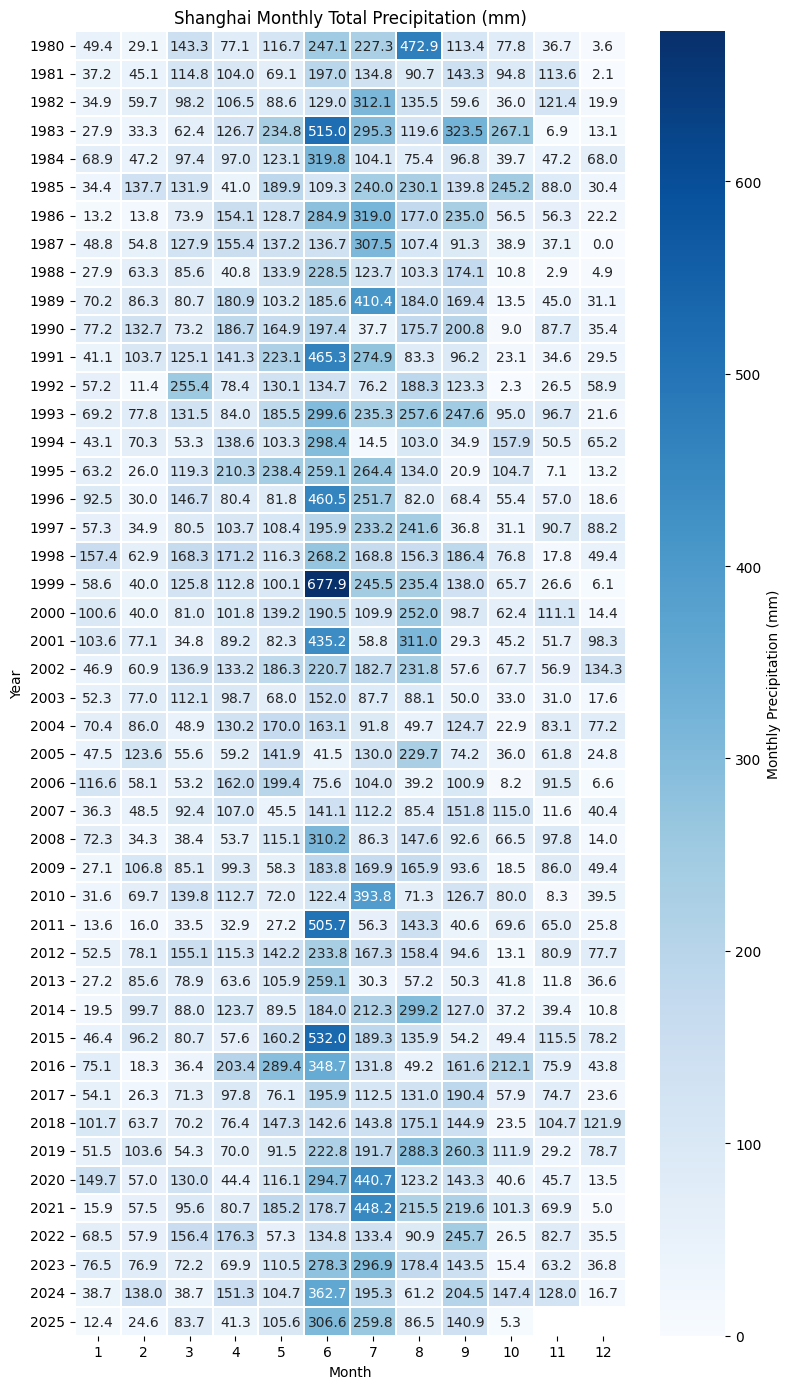

In [157]:
monthly_prcp = (
    df.assign(year=df["time"].dt.year, month=df["time"].dt.month)
      .groupby(["year","month"])["precipitation_sum"]
      .sum().unstack()   # use sum, not mean
)
plt.figure(figsize=(8,14))
sns.heatmap(monthly_prcp, cmap="Blues",
            cbar_kws={"label":"Monthly Precipitation (mm)"},
            linewidths=.3, annot=True, fmt=".1f")
plt.title("Shanghai Monthly Total Precipitation (mm)")
plt.xlabel("Month"); plt.ylabel("Year")
plt.tight_layout(); plt.show()


In [158]:
# sns.heatmap(monthly.T, annot=True)

## Loading the HOURLY dataset

In [2]:
start = datetime(2014, 1, 1)
end = datetime(2025, 10, 30)
location = Point(31.4, 121.4667, 7)

baoshan_hourly = Hourly(location, start, end)
baoshan_hourly = baoshan_hourly.fetch()

In [3]:
baoshan_hourly.isna().sum(), baoshan_hourly.shape

(temp        63
 dwpt        63
 rhum        63
 prcp     74130
 snow    103463
 wdir      2033
 wspd       172
 wpgt    103330
 pres     14962
 tsun     99569
 coco     34315
 dtype: int64,
 (103463, 11))

In [13]:
# {'latitude': 31.1667, 'longitude': 121.4333, 'elevation': 7},
start = datetime(2014, 1, 1)
end = datetime(2025, 10, 30)
location = Point(31.1667, 121.4333, 7)
# Get daily data for 2018
xuhui_hourly = Hourly(location, start, end)
xuhui_hourly = xuhui_hourly.fetch()

In [14]:
xuhui_hourly.isna().sum(), xuhui_hourly.shape

(temp        63
 dwpt        63
 rhum        63
 prcp     74130
 snow    103463
 wdir      2033
 wspd       172
 wpgt    103330
 pres     14962
 tsun     99569
 coco     34315
 dtype: int64,
 (103463, 11))

In [20]:
display(xuhui_hourly.head(3))
display(baoshan_hourly.head(3))

,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2014-01-01 00:00:00,4.0,-4.0,56.0,<NA>,<NA>,230.0,7.2,<NA>,<NA>,<NA>,<NA>
2014-01-01 01:00:00,7.0,-3.8,46.0,<NA>,<NA>,230.0,10.8,<NA>,<NA>,<NA>,<NA>
2014-01-01 02:00:00,10.0,-5.1,34.0,<NA>,<NA>,240.0,14.4,<NA>,<NA>,<NA>,<NA>


,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2014-01-01 00:00:00,4.0,-4.0,56.0,<NA>,<NA>,230.0,7.2,<NA>,<NA>,<NA>,<NA>
2014-01-01 01:00:00,7.0,-3.8,46.0,<NA>,<NA>,230.0,10.8,<NA>,<NA>,<NA>,<NA>
2014-01-01 02:00:00,10.0,-5.1,34.0,<NA>,<NA>,240.0,14.4,<NA>,<NA>,<NA>,<NA>


In [19]:
display(xuhui_hourly.tail(3))
display(baoshan_hourly.tail(3))

,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2025-10-20 20:00:00,14.3,13.0,92.0,<NA>,<NA>,41.0,9.3,<NA>,1020.3,0.0,<NA>
2025-10-20 21:00:00,14.1,12.8,92.0,<NA>,<NA>,42.0,9.3,<NA>,1020.4,0.0,<NA>
2025-10-20 22:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,<NA>


,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2025-10-20 20:00:00,16.9,14.2,84.0,<NA>,<NA>,287.0,5.5,<NA>,1019.8,0.0,<NA>
2025-10-20 21:00:00,16.9,14.2,84.0,<NA>,<NA>,287.0,5.5,<NA>,1019.9,0.0,<NA>
2025-10-20 22:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,<NA>


In [17]:
baoshan_hourly.tail(3)

,temp,dwpt,rhum,prcp,snow,wdir,wspd,wpgt,pres,tsun,coco
time,,,,,,,,,,,
2025-10-20 20:00:00,16.9,14.2,84.0,<NA>,<NA>,287.0,5.5,<NA>,1019.8,0.0,<NA>
2025-10-20 21:00:00,16.9,14.2,84.0,<NA>,<NA>,287.0,5.5,<NA>,1019.9,0.0,<NA>
2025-10-20 22:00:00,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,0.0,<NA>


In [24]:
# checking how different the measurements in each district are
target_cols  = ['temp', 'rhum', 'prcp', 'wspd', 'pres']
df_difference = pd.DataFrame()
for col in target_cols:
    df_difference[col] = abs(baoshan_hourly[col] - xuhui_hourly[col])

In [26]:
df_difference.describe()

,temp,rhum,prcp,wspd,pres
count,103400.0,103400.0,29333.0,103291.0,88501.0
mean,0.676678,4.050986,0.10779,3.121698,0.56886
std,0.866961,5.104198,0.564981,3.792221,0.586346
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0
50%,0.3,2.0,0.0,1.7,0.4
75%,1.1,7.0,0.0,5.1,0.9
max,11.0,42.0,18.5,50.1,16.5


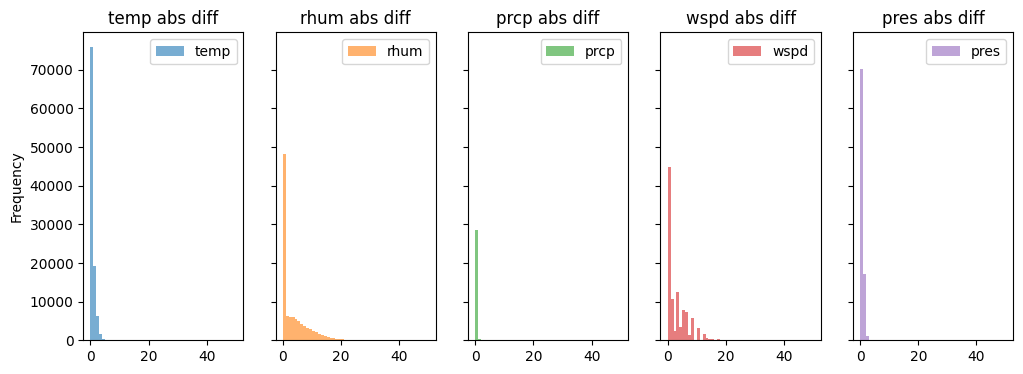

In [37]:
df_difference[target_cols].plot.hist(
    bins=50, alpha=0.6, figsize=(12,4), subplots=True, layout=(1,len(target_cols)),
    sharey=True, title=[f"{c} abs diff" for c in target_cols]
);

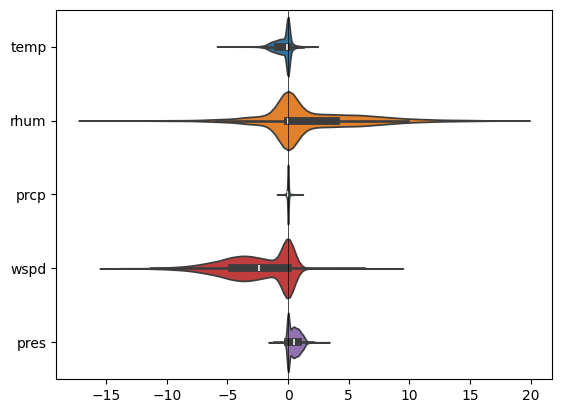

In [32]:
#windspeed in baoshan seems lower - consistently
diff_signed = baoshan_hourly[target_cols] - xuhui_hourly[target_cols]
diff_daily = diff_signed.resample("D").mean()
sns.violinplot(data=diff_daily[target_cols], orient="h", cut=0)
plt.axvline(0, color="k", lw=0.5);


In [52]:
print(baoshan_hourly.loc['2019-09-02':'2019-09-03', ['temp','prcp']])


                     temp  prcp
time                           
2019-09-02 00:00:00  23.4  <NA>
2019-09-02 01:00:00  24.0  <NA>
2019-09-02 02:00:00  24.7  <NA>
2019-09-02 03:00:00  25.1  <NA>
2019-09-02 04:00:00  24.9  <NA>
2019-09-02 05:00:00  24.7  <NA>
2019-09-02 06:00:00  24.1  <NA>
2019-09-02 07:00:00  24.2  <NA>
2019-09-02 08:00:00  24.3  <NA>
2019-09-02 09:00:00  24.0  <NA>
2019-09-02 10:00:00  23.8  <NA>
2019-09-02 11:00:00  23.5  <NA>
2019-09-02 12:00:00  23.1  <NA>
2019-09-02 13:00:00  23.1  <NA>
2019-09-02 14:00:00  23.0  <NA>
2019-09-02 15:00:00  22.8  <NA>
2019-09-02 16:00:00  22.8  <NA>
2019-09-02 17:00:00  22.7  <NA>
2019-09-02 18:00:00  22.3  <NA>
2019-09-02 19:00:00  22.4  <NA>
2019-09-02 20:00:00  22.4  <NA>
2019-09-02 21:00:00  22.4  <NA>
2019-09-02 22:00:00  22.7  <NA>
2019-09-02 23:00:00  23.2  <NA>
2019-09-03 00:00:00  23.4  <NA>
2019-09-03 01:00:00  24.2  <NA>
2019-09-03 02:00:00  25.0  <NA>
2019-09-03 03:00:00  25.4  <NA>
2019-09-03 04:00:00  25.4  <NA>
2019-09-

## Getting AQI Data

In [6]:
!ls src/data

'Shanghai AQI and Wheather 2014-2021.csv'   shanghai.csv
 lite.json				    shanghai_aqi.csv
 shanghai-air-quality.csv


In [ ]:
hongqiao_df.isna().sum()

In [ ]:
hongqiao_df.columns

In [ ]:
baoshan_cols = [f'baoshan_{i}' for i in cols_to_keep]
xuhui_cols = [f'xuhui_{i}' for i in cols_to_keep]
baoshan_cols, xuhui_cols

In [ ]:
!ls src/data
fp = 'src/data/Shanghai AQI and Wheather 2014-2021.csv'
kaggle_df = pd.read_csv(fp)

In [ ]:
cols_to_keep

In [ ]:
cols_to_keep = ['time','tavg', 'tmin', 'tmax', 'prcp', 'wspd', 'pres']
hongqiao_df = hongqiao_df.reset_index()[cols_to_keep]
shanghai_df = shanghai_df.reset_index()[cols_to_keep]

In [ ]:
hongqiao_df.columns = xuhui_cols
shanghai_df.columns =  baoshan_cols

In [ ]:
kaggle_df

In [ ]:
# !ls src/data
aqifp = 'src/data/shanghai_aqi.csv'
aqi_df = pd.read_csv(aqifp)
aqi_df.isna().sum()

In [ ]:
aqi_df.info()